Построение DotPlot для оценки синтении


In [3]:
!pip install Bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.3/321.3 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.6 MB/s eta 0:00:00


In [16]:
import matplotlib.pyplot as plt
import numpy as np
from Bio import SeqIO
import os
import time

In [14]:
def load_sequences(neanderthal_file="neand.fasta", human_file="sap.fasta"):
    if not os.path.exists(neanderthal_file):
        raise FileNotFoundError(f"Файл {neanderthal_file} не найден!")
    if not os.path.exists(human_file):
        raise FileNotFoundError(f"Файл {human_file} не найден!")

    neanderthal_record = SeqIO.read(neanderthal_file, "fasta")
    human_record = SeqIO.read(human_file, "fasta")

    neanderthal_seq = str(neanderthal_record.seq).upper()
    human_seq = str(human_record.seq).upper()

    print(f"  Неандерталец ({neanderthal_file}):")
    print(f"    ID: {neanderthal_record.id}")
    print(f"    Описание: {neanderthal_record.description}")
    print(f"    Длина: {len(neanderthal_seq)} п.н.")

    print(f"\n  Человек ({human_file}):")
    print(f"    ID: {human_record.id}")
    print(f"    Описание: {human_record.description}")
    print(f"    Длина: {len(human_seq)} п.н.")

    return neanderthal_seq, human_seq


In [17]:
def create_dotplot_kmer(seq1, seq2, kmer_size=12, max_points=50000):
    start_time = time.time()

    n, m = len(seq1), len(seq2)
    print(f"Размеры матрицы: {n} x {m} = {n*m:,} потенциальных точек")

    index = {}
    for i in range(n - kmer_size + 1):
        kmer = seq1[i:i+kmer_size]
        if kmer not in index:
            index[kmer] = []
        index[kmer].append(i)

    print(f"  Найдено {len(index)} уникальных k-меров")

    points_x = []
    points_y = []
    sampling_step = max(1, (m - kmer_size + 1) // (max_points // len(index) + 1))

    for j in range(0, m - kmer_size + 1, sampling_step):
        kmer = seq2[j:j+kmer_size]
        if kmer in index:
            for i in index[kmer]:
                points_x.append(i)
                points_y.append(j)

    elapsed_time = time.time() - start_time
    print(f"  Найдено {len(points_x):,} совпадающих позиций за {elapsed_time:.2f} сек.")

    return points_x, points_y


In [18]:
def create_dotplot_window(seq1, seq2, window=20, threshold=15, step=10):
    start_time = time.time()

    n, m = len(seq1), len(seq2)
    points_x = []
    points_y = []

    total_windows = ((n - window) // step + 1) * ((m - window) // step + 1)
    print(f"  Всего окон для сравнения: {total_windows:,}")

    processed = 0
    for i in range(0, n - window, step):
        if processed % 100000 == 0:
            print(f"    Обработано {processed}/{total_windows} окон...")

        for j in range(0, m - window, step):
            matches = 0
            for k in range(window):
                if seq1[i+k] == seq2[j+k]:
                    matches += 1

            if matches >= threshold:
                points_x.append(i + window//2)
                points_y.append(j + window//2)

            processed += 1

    elapsed_time = time.time() - start_time
    print(f"  Найдено {len(points_x):,} совпадений за {elapsed_time:.2f} сек.")

    return points_x, points_y

In [25]:
def plot_dotplot(points_x, points_y, seq1_len, seq2_len,
                 seq1_name="Неандерталец", seq2_name="Человек",
                 save_path="mitochondrial_dotplot.png"):
    plt.figure(figsize=(14, 12))

    if len(points_x) > 100000:
        print("\nСоздание гистограммы плотности точек...")
        heatmap, xedges, yedges = np.histogram2d(
            points_x, points_y,
            bins=[min(500, seq1_len//100), min(500, seq2_len//100)]
        )

        plt.imshow(heatmap.T,
                  origin='lower',
                  extent=[0, seq1_len, 0, seq2_len],
                  cmap='YlOrRd',
                  aspect='auto',
                  interpolation='nearest')
        plt.colorbar(label='Плотность совпадений')
    else:
        plt.scatter(points_x, points_y, s=1, alpha=0.8, c='black', marker='.')

    max_len = max(seq1_len, seq2_len)
    plt.plot([0, max_len], [0, max_len], 'b--', alpha=0.5, linewidth=1,
             label='Главная диагональ (полная идентичность)')
    offsets = [-500, -200, 200, 500]
    for offset in offsets:
        plt.plot([0, max_len], [offset, max_len + offset],
                'g:', alpha=0.2, linewidth=0.5)

    plt.title(f"DotPlot: Митохондриальные геномы\n{seq1_name} vs {seq2_name}",
              fontsize=16, fontweight='bold')
    plt.xlabel(f"{seq1_name} (позиция, п.н.)", fontsize=12)
    plt.ylabel(f"{seq2_name} (позиция, п.н.)", fontsize=12)

    plt.xlim(0, seq1_len)
    plt.ylim(0, seq2_len)
    plt.gca().set_aspect('equal')
    plt.grid(True, alpha=0.2, linestyle='--')
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\nГрафик сохранен в файл: {save_path}")
    plt.show()


In [21]:
def analyze_synteny(points_x, points_y, seq1_len, seq2_len):

    if len(points_x) == 0:
        print("Недостаточно точек для анализа!")
        return

    points = np.column_stack((points_x, points_y))

    diagonal_distances = points[:, 1] - points[:, 0]

    print(f"   Среднее отклонение: {np.mean(diagonal_distances):.2f} п.н.")
    print(f"   Медианное отклонение: {np.median(diagonal_distances):.2f} п.н.")
    print(f"   Стандартное отклонение: {np.std(diagonal_distances):.2f} п.н.")
    print(f"   95-й процентиль: {np.percentile(np.abs(diagonal_distances), 95):.2f} п.н.")

    inverse_dist = abs(points[:, 1] - (seq2_len - points[:, 0]))
    inverse_points = points[inverse_dist < 500]

    inverse_percentage = len(inverse_points) / len(points) * 100
    print(f"   Точек на обратной диагонали: {len(inverse_points)} ({inverse_percentage:.2f}%)")

    if inverse_percentage > 1:
        print(f"   Есть потенциальные инверсии ({inverse_percentage:.1f}% точек)")
    else:
        print(f"   Крупных инверсий не обнаружено")

In [22]:
def create_comparison_summary(seq1, seq2):
    print(f"  Длина генома неандертальца: {len(seq1):,} п.н.")
    print(f"  Длина генома человека: {len(seq2):,} п.н.")
    print(f"  Разница в длине: {abs(len(seq1) - len(seq2))} п.н.")

    gc1 = (seq1.count('G') + seq1.count('C')) / len(seq1) * 100
    gc2 = (seq2.count('G') + seq2.count('C')) / len(seq2) * 100

    print(f"\nGC-состав:")
    print(f"  Неандерталец: {gc1:.2f}%")
    print(f"  Человек: {gc2:.2f}%")
    print(f"  Разница: {abs(gc1 - gc2):.2f}%")

  Неандерталец (neand.fasta):
    ID: NC_011137.1
    Описание: NC_011137.1 Homo sapiens neanderthalensis mitochondrion, complete genome
    Длина: 16565 п.н.

  Человек (sap.fasta):
    ID: NC_012920.1
    Описание: NC_012920.1 Homo sapiens mitochondrion, complete genome
    Длина: 16569 п.н.
  Длина генома неандертальца: 16,565 п.н.
  Длина генома человека: 16,569 п.н.
  Разница в длине: 4 п.н.

GC-состав:
  Неандерталец: 44.39%
  Человек: 44.36%
  Разница: 0.03%
1. Метод k-меров (быстрый, рекомендуется для больших последовательностей)
2. Метод скользящего окна (медленный, более точный)

Выберите метод (1 или 2, Enter для метода 1): 1
Длина k-мера (Enter для 12): 
Макс. точек (Enter для 50000): 
Размеры матрицы: 16565 x 16569 = 274,465,485 потенциальных точек
  Найдено 16520 уникальных k-меров
  Найдено 5 совпадающих позиций за 0.01 сек.

График сохранен в файл: mitochondrial_dotplot.png


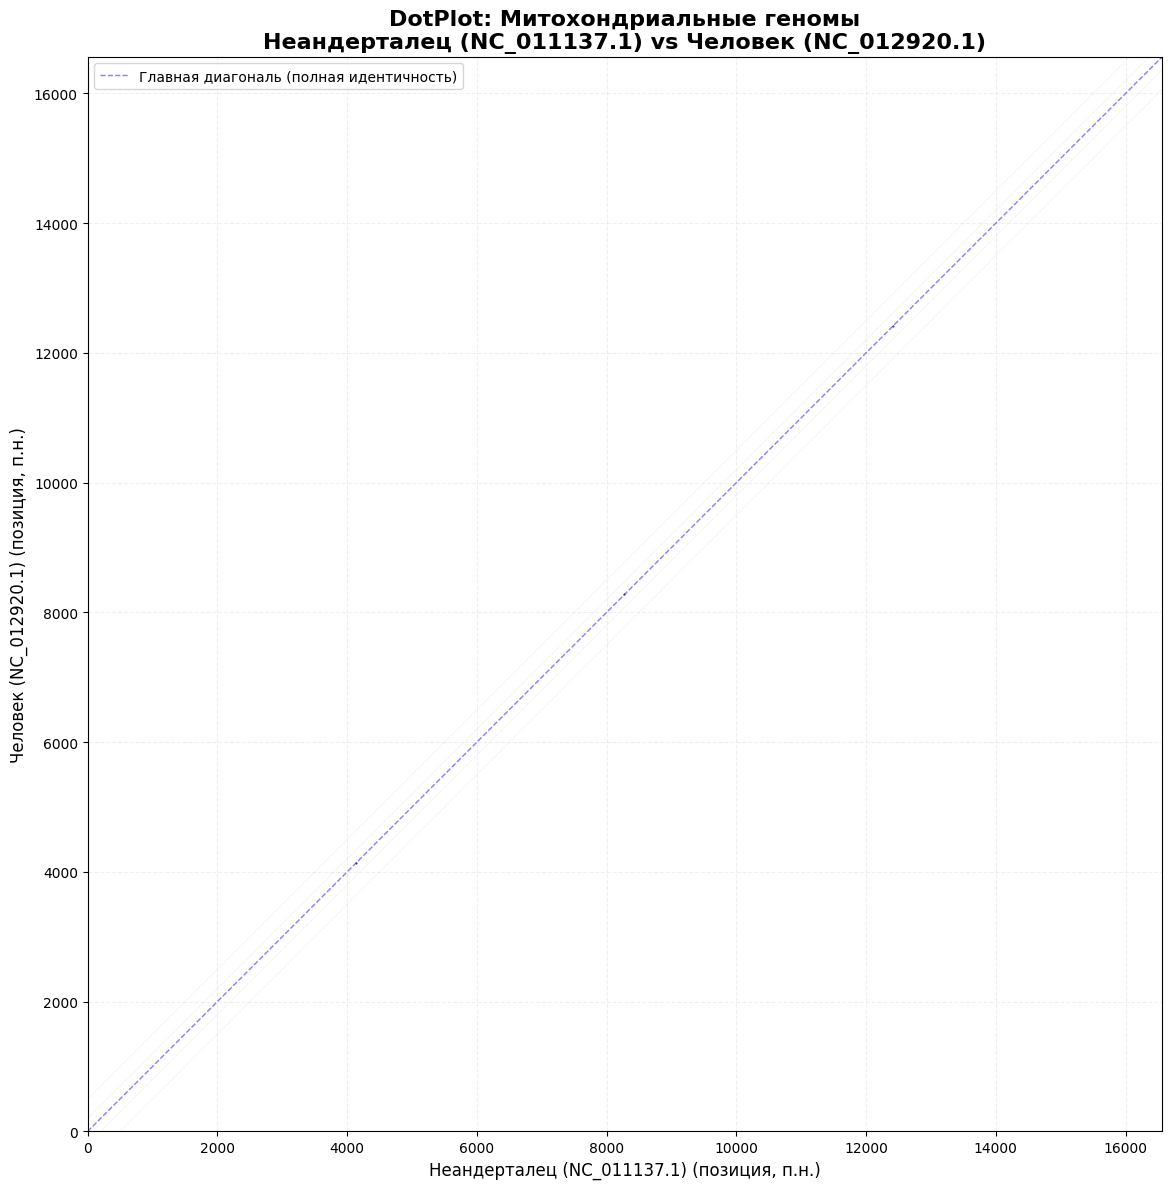

   Среднее отклонение: 3.80 п.н.
   Медианное отклонение: 5.00 п.н.
   Стандартное отклонение: 1.94 п.н.
   95-й процентиль: 5.00 п.н.
   Точек на обратной диагонали: 1 (20.00%)
   Есть потенциальные инверсии (20.0% точек)


In [26]:
def main():
    try:
        neanderthal_seq, human_seq = load_sequences(
            "neand.fasta",
            "sap.fasta"
        )

        create_comparison_summary(neanderthal_seq, human_seq)

        print("1. Метод k-меров (быстрый, рекомендуется для больших последовательностей)")
        print("2. Метод скользящего окна (медленный, более точный)")

        choice = input("\nВыберите метод (1 или 2, Enter для метода 1): ").strip()

        if choice == "2":
            window = int(input("Размер окна (Enter для 20): ") or "20")
            threshold = int(input("Порог совпадений (Enter для 15): ") or "15")
            step = int(input("Шаг (Enter для 10): ") or "10")

            points_x, points_y = create_dotplot_window(
                neanderthal_seq, human_seq,
                window=window, threshold=threshold, step=step
            )
        else:
            kmer = int(input("Длина k-мера (Enter для 12): ") or "12")
            max_points = int(input("Макс. точек (Enter для 50000): ") or "50000")

            points_x, points_y = create_dotplot_kmer(
                neanderthal_seq, human_seq,
                kmer_size=kmer, max_points=max_points
            )
        plot_dotplot(
            points_x, points_y,
            len(neanderthal_seq), len(human_seq),
            "Неандерталец (NC_011137.1)",
            "Человек (NC_012920.1)",
            "mitochondrial_dotplot.png"
        )

        # Анализ
        analyze_synteny(points_x, points_y, len(neanderthal_seq), len(human_seq))
    except FileNotFoundError as e:
        print(f"\nОШИБКА: {e}")
if __name__ == "__main__":
    main()

Митохондриальные геномы человека и неандертальца демонстрируют высокую степень
синтении. Основная масса точек на графике лежит вдоль главной диагонали, что
указывает на коллинеарное расположение гомологичных участков. Не наблюдается
крупных инверсий, делеций или дупликаций. Это подтверждает известный факт
высокого сходства митохондриальных геномов